# 08 — Walk-Forward Backtest: Dual-Direction + Take-Profit Sweep

Anchored **walk-forward** (no random/k-fold — TFEX rule #6) over the full **2016→2026** history
(17,002 1H bars, 38 windows), driving the Phase-7 risk engine on Phase-5 signals with the
**realistic cost model** (160 THB round-trip commission + quarterly roll-over penalty).

**Goal:** hedge the long-only `csm-set` macro book by letting Strategy B (1H ORB) capture
**downside alpha via shorts** in bear regimes. We compare **Long-only vs Short-only vs
Dual-Direction**, each across a **Take-Profit sweep** (No-TP / 1.5R / 2.0R / 2.5R / 3.0R) with the
stop fixed at `k_atr_stop=2.0`.

- **Directional gate:** longs gate to Daily `trend_up`; shorts gate to Daily `trend_down`
  (`signals.gate.apply_regime_gate`, config-driven via `allowed_regimes` / `short_allowed_regimes`).
- **Take-Profit:** full close-out at the target via `partial_fraction=1.0`; "No TP" uses an
  unreachable `partial_tp_r` ⇒ pure ATR-stop + time-stop.
- **Data:** local Parquet snapshot only — never tvkit.

In [1]:
# Path fix: when run from notebooks/ (Jupyter sets cwd there), chdir to the project root so
# ``data/`` and ``results/`` resolve and the package imports from the editable install.
import os

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import polars as pl

from tfex_s50_multi_tf_swing.backtest.data_source import build_execution_bars, load_continuous_frames
from tfex_s50_multi_tf_swing.backtest.models import WalkForwardConfig
from tfex_s50_multi_tf_swing.backtest.walk_forward import run_walk_forward
from tfex_s50_multi_tf_swing.config.settings import get_settings
from tfex_s50_multi_tf_swing.data.store import ParquetStore
from tfex_s50_multi_tf_swing.execution.models import ExecutionConfig
from tfex_s50_multi_tf_swing.risk.models import LadderEvidence, RiskConfig
from tfex_s50_multi_tf_swing.signals.gate import build_detect_map
from tfex_s50_multi_tf_swing.signals.inputs import build_signal_inputs

In [2]:
# Load 1h + 1d frames (1H-execution migration). 1D carries regime + bias.
settings = get_settings()
store = ParquetStore(settings.data_dir)
frames = load_continuous_frames(store, with_4h=False)
sig_cfg = settings.signal_config()
inputs = build_signal_inputs(
    frames,
    regime_thresholds=settings.regime_thresholds(),
    bias_config=settings.bias_config(),
    signal_config=sig_cfg,
)
raw_bars = build_execution_bars(frames["1h"])  # 1H execution bars
print(f"1H bars: {raw_bars.height}  |  signal-input rows: {inputs.height}")

# Full-history anchored windows.
WF = WalkForwardConfig(train_span_days=240, test_span_days=90, step_days=90)

# A backtest measures scaled-capacity edge, so evaluate at the `scale` rung with full evidence
# (the live ladder stays env-gated; `paper` caps to 0 contracts and would take no trades).
EVIDENCE = LadderEvidence(months_live=120.0, expectancy_stable=True, drawdown_within_budget=True)


def backtest_risk(**overrides: object) -> RiskConfig:
    """Settings risk config forced to the `scale` rung, with optional field overrides."""
    base = settings.risk_config().model_dump()
    base["deployment_stage"] = "scale"
    base.update(overrides)
    return RiskConfig(**base)


TREND_UP = frozenset({"trend_up"})
TREND_DOWN = frozenset({"trend_down"})
EMPTY: frozenset[str] = frozenset()

# Three direction policies via the new directional regime gate (longs↔trend_up, shorts↔trend_down).
DIRECTION_MODES: dict[str, dict[str, frozenset[str]]] = {
    "Long-only": {"long_regimes": TREND_UP, "short_regimes": EMPTY},
    "Short-only": {"long_regimes": EMPTY, "short_regimes": TREND_DOWN},
    "Dual-Direction": {"long_regimes": TREND_UP, "short_regimes": TREND_DOWN},
}

# Take-Profit sweep (stop fixed at k_atr_stop=2.0). "No TP" => unreachable partial target, so the
# position exits only on the ATR stop or time-stop; a fixed full TP at X R uses partial_fraction=1.0.
TP_LABELS = ["No TP", "1.5R", "2.0R", "2.5R", "3.0R"]


def exec_for_tp(label: str) -> ExecutionConfig:
    base = settings.execution_config().model_dump()
    base["k_atr_stop"] = 2.0
    if label == "No TP":
        base["partial_tp_r"] = 100.0  # unreachable target -> ATR-stop / time-stop only
        base["partial_fraction"] = 0.5  # moot (never reached)
    else:
        base["partial_tp_r"] = float(label.rstrip("R"))
        base["partial_fraction"] = 1.0  # full close-out at the target
    return ExecutionConfig(**base)


print("directions:", list(DIRECTION_MODES), "| TP sweep:", TP_LABELS)

1H bars: 17002  |  signal-input rows: 17002
directions: ['Long-only', 'Short-only', 'Dual-Direction'] | TP sweep: ['No TP', '1.5R', '2.0R', '2.5R', '3.0R']


In [3]:
# Run 3 directions × 5 TP configs on the full 38-window history (160 THB round-trip + roll-over).
COST = settings.cost_model()


def run_combo(direction_label: str, tp_label: str):
    detect = build_detect_map(
        sig_cfg, enabled=frozenset({"B"}), **DIRECTION_MODES[direction_label]
    )
    rep = run_walk_forward(
        inputs=inputs,
        raw_bars=raw_bars,
        detect=detect,
        wf_config=WF,
        exec_config=exec_for_tp(tp_label),
        risk_config=backtest_risk(),
        cost_model=COST,
        ladder_evidence=EVIDENCE,
    )
    o = rep.combined.overall
    sharpe = rep.combined.ratios.sharpe
    row = {
        "direction": direction_label,
        "take_profit": tp_label,
        "n_trades": o.n_trades,
        "win_rate": round(float(o.win_rate), 3),
        "max_dd_r": round(float(rep.combined.drawdown.depth_r), 3),
        "expectancy_r": round(float(o.expectancy_r), 4),
        "sharpe": round(sharpe, 3) if sharpe is not None else None,
        "avg_hold_h": round(o.avg_holding_hours, 2) if o.avg_holding_hours is not None else None,
        "avg_hold_days": (
            round(o.avg_holding_market_days, 2) if o.avg_holding_market_days is not None else None
        ),
    }
    return rep, row


rows: list[dict[str, object]] = []
reports: dict[tuple[str, str], object] = {}
for dlabel in DIRECTION_MODES:
    for tp in TP_LABELS:
        rep, row = run_combo(dlabel, tp)
        rows.append(row)
        reports[(dlabel, tp)] = rep

n_windows = len(next(iter(reports.values())).windows)
print(f"ran {len(rows)} configs over {n_windows} windows")

ran 15 configs over 38 windows


## Comparison — Long-only vs Short-only vs Dual-Direction × Take-Profit sweep

One row per (direction, take-profit). Metrics on the **combined** book over all 38 windows, net of
the 160 THB round-trip commission and the quarterly roll-over penalty:
**Total Trades · Win Rate · Max Drawdown (R) · Expectancy (R) · Sharpe · Avg Holding Time**.

In [4]:
# Comprehensive comparison table (15 rows): direction × take-profit.
comparison = pl.DataFrame(rows)
with pl.Config(tbl_rows=-1, tbl_cols=-1, fmt_str_lengths=40):
    print("Dual-Direction × Take-Profit sweep — combined book, 38 windows, full costs:\n")
    print(comparison)

# Best config by expectancy, and the best within each direction.
best = comparison.sort("expectancy_r", descending=True).row(0, named=True)
print(
    f"\nBest overall by expectancy: {best['direction']} @ {best['take_profit']} → "
    f"expectancy {best['expectancy_r']:+.4f}R | max_dd {best['max_dd_r']}R | "
    f"win {best['win_rate']:.1%} | trades {best['n_trades']} | avg hold {best['avg_hold_h']}h"
)
print("\nBest take-profit within each direction (by expectancy):")
print(
    comparison.sort("expectancy_r", descending=True)
    .group_by("direction", maintain_order=True)
    .first()
    .select("direction", "take_profit", "n_trades", "win_rate", "max_dd_r", "expectancy_r", "sharpe")
)

Dual-Direction × Take-Profit sweep — combined book, 38 windows, full costs:

shape: (15, 9)
┌───────────┬───────────┬──────────┬──────────┬──────────┬──────────┬────────┬──────────┬──────────┐
│ direction ┆ take_prof ┆ n_trades ┆ win_rate ┆ max_dd_r ┆ expectan ┆ sharpe ┆ avg_hold ┆ avg_hold │
│ ---       ┆ it        ┆ ---      ┆ ---      ┆ ---      ┆ cy_r     ┆ ---    ┆ _h       ┆ _days    │
│ str       ┆ ---       ┆ i64      ┆ f64      ┆ f64      ┆ ---      ┆ f64    ┆ ---      ┆ ---      │
│           ┆ str       ┆          ┆          ┆          ┆ f64      ┆        ┆ f64      ┆ f64      │
╞═══════════╪═══════════╪══════════╪══════════╪══════════╪══════════╪════════╪══════════╪══════════╡
│ Long-only ┆ No TP     ┆ 24       ┆ 0.375    ┆ 6.405    ┆ 0.1307   ┆ 0.07   ┆ 7.12     ┆ 0.89     │
│ Long-only ┆ 1.5R      ┆ 22       ┆ 0.364    ┆ 5.501    ┆ -0.1119  ┆ -0.123 ┆ 6.23     ┆ 0.78     │
│ Long-only ┆ 2.0R      ┆ 22       ┆ 0.364    ┆ 5.701    ┆ -0.1328  ┆ -0.146 ┆ 6.68     ┆ 0.84     │

## Per-window NAV — best Dual-Direction take-profit

NAV index (base 100) per window, drawdown depth, trades taken, average holding hours, and the
circuit-breaker flag — for the best Dual-Direction take-profit by expectancy. Public-safe
(counts / R-metrics / NAV only, never raw OHLCV).

Best Dual-Direction take-profit: No TP
Per-window NAV (traded windows only):
shape: (20, 7)
┌────────┬────────────┬─────────┬───────────┬──────────┬────────────┬─────────────────┐
│ window ┆ test_start ┆ n_taken ┆ nav_index ┆ max_dd_r ┆ avg_hold_h ┆ breaker_tripped │
│ ---    ┆ ---        ┆ ---     ┆ ---       ┆ ---      ┆ ---        ┆ ---             │
│ i64    ┆ str        ┆ i64     ┆ f64       ┆ f64      ┆ f64        ┆ bool            │
╞════════╪════════════╪═════════╪═══════════╪══════════╪════════════╪═════════════════╡
│ 1      ┆ 2017-04-29 ┆ 4       ┆ 100.653   ┆ 1.606    ┆ 6.25       ┆ false           │
│ 2      ┆ 2017-07-28 ┆ 5       ┆ 105.764   ┆ 0.405    ┆ 8.0        ┆ false           │
│ 4      ┆ 2018-01-24 ┆ 1       ┆ 99.117    ┆ 1.132    ┆ 6.0        ┆ false           │
│ 5      ┆ 2018-04-24 ┆ 1       ┆ 101.453   ┆ 0.0      ┆ 8.0        ┆ false           │
│ 7      ┆ 2018-10-21 ┆ 2       ┆ 99.562    ┆ 1.121    ┆ 5.0        ┆ false           │
│ 8      ┆ 2019-01-19 ┆ 4   

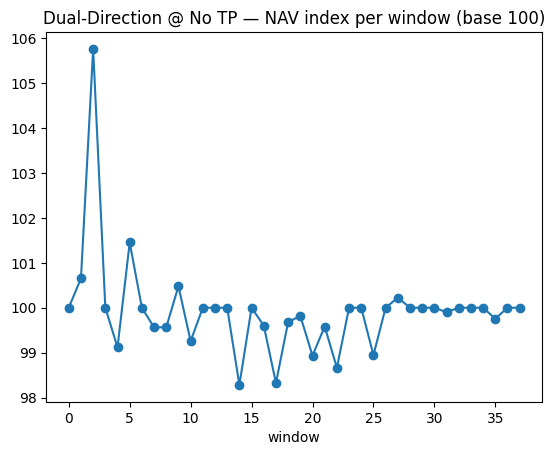

In [5]:
# Per-window NAV for the best Dual-Direction take-profit (by expectancy).
dual_rows = [r for r in rows if r["direction"] == "Dual-Direction"]
best_dual_tp = max(dual_rows, key=lambda r: r["expectancy_r"])["take_profit"]
best_report = reports[("Dual-Direction", best_dual_tp)]
print(f"Best Dual-Direction take-profit: {best_dual_tp}")

nav_rows = [
    {
        "window": w.window.index,
        "test_start": w.window.test_start.date().isoformat(),
        "n_taken": w.n_taken,
        "nav_index": round(w.nav_index, 3),
        "max_dd_r": round(float(w.drawdown.depth_r), 3),
        "avg_hold_h": w.metrics.avg_holding_hours,
        "breaker_tripped": w.circuit_breaker_tripped,
    }
    for w in best_report.combined.windows
]
nav_df = pl.DataFrame(nav_rows)
traded = nav_df.filter(pl.col("n_taken") > 0)
with pl.Config(tbl_rows=-1, tbl_cols=-1):
    print("Per-window NAV (traded windows only):")
    print(traded)
print(f"\n{nav_df.height} windows total, {traded.height} with trades.")
if nav_df.height:
    nav_df.to_pandas().set_index("window")["nav_index"].plot(
        title=f"Dual-Direction @ {best_dual_tp} — NAV index per window (base 100)", marker="o"
    )

## Deep-Dive — macro-correlated trade log (top config: Long-only · No TP)

Full trade history (all 24 trades across the 38 windows) for cross-referencing entry/exit dates
against real-world market events, followed by advanced descriptive stats: **Profit Factor**,
**Payoff Ratio**, **tail/fat-tail analysis** (max win + top-3 runners — the right tail that carries
the No-TP edge), and a **holding-time profile** split Winners vs Losers. All R-multiples are **net**
of the 160 THB round-trip commission and quarterly roll-over penalty. Trades are read from
`WindowResult.trades` (a `list[CostedTrade]`: gross `Trade` + net R + cost breakdown).

In [6]:
# ============================================================================================
# Deep-Dive Analysis — macro-correlated trade log for the top config ("Long-only", "No TP")
# ============================================================================================
# Each WindowResult now retains its taken trades as a list[CostedTrade] on ``w.trades`` (Phase-8
# harness). A CostedTrade carries the gross ``Trade`` (entry/exit times + prices, gross R, exit
# reason, regime) plus ``net_r_multiple`` — fully net of the 160 THB round-trip commission and the
# quarterly roll-over penalty (Phase-8 cost model, sized by the Phase-7 risk engine).
CONFIG = ("Long-only", "No TP")
report = reports[CONFIG]

# --- 1) Trade log: iterate all 38 windows, flatten every taken trade ---
trade_rows = []
for w in report.combined.windows:
    for ct in w.trades:  # list[CostedTrade]
        g = ct.gross  # the gross execution.Trade
        holding_hours = (g.exit_time - g.entry_time).total_seconds() / 3600.0  # precise wall-clock
        net_r = float(ct.net_r_multiple)
        outcome = "Win" if net_r > 0 else ("Loss" if net_r < 0 else "Scratch")
        trade_rows.append(
            {
                "window": w.window.index,
                "entry_time": g.entry_time,
                "exit_time": g.exit_time,
                "holding_hours": round(holding_hours, 2),
                "entry_price": float(g.entry),
                "exit_price": float(g.exit_price),
                "gross_r": round(float(g.r_multiple), 4),
                "net_r": round(net_r, 4),
                "outcome": outcome,
            }
        )

trade_log = pl.DataFrame(trade_rows).sort("entry_time")
print(f"=== Trade Log — {CONFIG[0]} / {CONFIG[1]} — {trade_log.height} trades ===")
with pl.Config(tbl_rows=-1, tbl_cols=-1, fmt_str_lengths=60):
    print(trade_log)  # tbl_rows=-1 ⇒ all rows, no ellipsis

# --- 2) Advanced performance metrics (computed on NET R — fully cost-laden) ---
wins = trade_log.filter(pl.col("net_r") > 0)
losses = trade_log.filter(pl.col("net_r") < 0)

gross_win_r = float(wins["net_r"].sum())
gross_loss_r = abs(float(losses["net_r"].sum()))
profit_factor = gross_win_r / gross_loss_r if gross_loss_r > 0 else float("inf")

avg_win_r = float(wins["net_r"].mean()) if wins.height else 0.0
avg_loss_r = abs(float(losses["net_r"].mean())) if losses.height else 0.0
payoff_ratio = avg_win_r / avg_loss_r if avg_loss_r > 0 else float("inf")

print("\n=== Advanced Performance Metrics (net of all costs) ===")
print(
    f"Trades: {trade_log.height} | Wins: {wins.height} | Losses: {losses.height} "
    f"| Scratches: {trade_log.height - wins.height - losses.height}"
)
print(f"Profit Factor  (Σ win R / |Σ loss R|)       : {profit_factor:.3f}")
print(
    f"Payoff Ratio   (avg win R / |avg loss R|)    : {payoff_ratio:.3f}  "
    f"(avg win {avg_win_r:+.3f}R, avg loss -{avg_loss_r:.3f}R)"
)
# Cross-check against the Phase-7/8 BacktestMetrics dataclass (same net-R basis).
_o = report.combined.overall
_pf_dc = _o.profit_factor
print(
    "  cross-check (BacktestMetrics): "
    f"profit_factor={float(_pf_dc) if _pf_dc is not None else None:.3f}, "
    f"expectancy_r={float(_o.expectancy_r):+.4f}, win_rate={float(_o.win_rate):.1%}"
)

# --- 3) Tail / fat-tail distribution — the right tail is where the No-TP edge lives ---
max_win_r = float(trade_log["net_r"].max())
print(f"\n=== Tail Distribution — Max Win {max_win_r:+.3f}R | Top 3 Largest Runners ===")
top3 = trade_log.sort("net_r", descending=True).head(3).select(
    "window", "entry_time", "exit_time", "holding_hours", "gross_r", "net_r"
)
with pl.Config(tbl_rows=-1, tbl_cols=-1):
    print(top3)

# --- 4) Holding-time profile (precise wall-clock hours): Winners vs Losers, side by side ---
print("\n=== Holding-Time Profile (hours) — Winners vs Losers ===")
holding_profile = (
    trade_log.filter(pl.col("outcome") != "Scratch")
    .group_by("outcome")
    .agg(
        pl.len().alias("n"),
        pl.col("holding_hours").min().alias("min_h"),
        pl.col("holding_hours").max().alias("max_h"),
        pl.col("holding_hours").median().alias("median_h"),
        pl.col("holding_hours").mean().round(2).alias("avg_h"),
    )
    .sort("outcome")
)
with pl.Config(tbl_rows=-1, tbl_cols=-1):
    print(holding_profile)

=== Trade Log — Long-only / No TP — 24 trades ===
shape: (24, 9)
┌────────┬───────────┬───────────┬───────────┬───────────┬───────────┬─────────┬─────────┬─────────┐
│ window ┆ entry_tim ┆ exit_time ┆ holding_h ┆ entry_pri ┆ exit_pric ┆ gross_r ┆ net_r   ┆ outcome │
│ ---    ┆ e         ┆ ---       ┆ ours      ┆ ce        ┆ e         ┆ ---     ┆ ---     ┆ ---     │
│ i64    ┆ ---       ┆ datetime[ ┆ ---       ┆ ---       ┆ ---       ┆ f64     ┆ f64     ┆ str     │
│        ┆ datetime[ ┆ μs, UTC]  ┆ f64       ┆ f64       ┆ f64       ┆         ┆         ┆         │
│        ┆ μs, UTC]  ┆           ┆           ┆           ┆           ┆         ┆         ┆         │
╞════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╪═════════╪═════════╪═════════╡
│ 1      ┆ 2017-07-1 ┆ 2017-07-1 ┆ 25.0      ┆ 830.65    ┆ 832.75    ┆ 0.8077  ┆ 0.4376  ┆ Win     │
│        ┆ 2         ┆ 3         ┆           ┆           ┆           ┆         ┆         ┆         │
│        ┆ 08:45:00  ┆ 09:

## Summary

- **Dual-direction shorts** are now config-driven: the directional regime gate
  (`apply_regime_gate`) gates longs to Daily `trend_up` and shorts to Daily `trend_down`
  (`SignalConfig.allowed_regimes` / `short_allowed_regimes`). Default stays long-only.
- The comparison table sweeps **Long-only / Short-only / Dual-Direction × {No-TP, 1.5R, 2.0R,
  2.5R, 3.0R}** over the full 2016→2026 history (38 windows), net of the 160 THB round-trip
  commission and the quarterly roll-over penalty.
- A fixed full take-profit (`partial_fraction=1.0`) trades win-rate for payoff; the table shows
  which (direction, TP) maximises expectancy and how Dual-Direction hedges drawdown vs Long-only.
- Engine / cost model / metrics / risk engine (Phase 7) run end-to-end; **real-money magnitudes
  stay data-gated** on a longer live sample — this is the mechanism + honest cost-laden estimate.